Saving shreshtha_stable_02.avi to shreshtha_stable_02.avi
Uploaded video: shreshtha_stable_02.avi

Preview frames:
Green box = detected face
Red dot = tracked head center


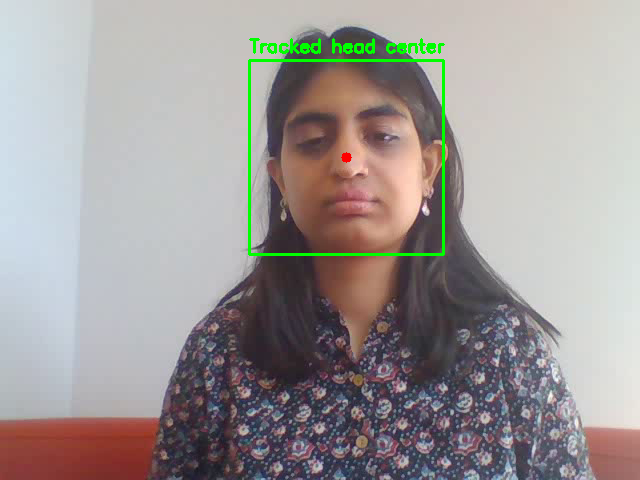

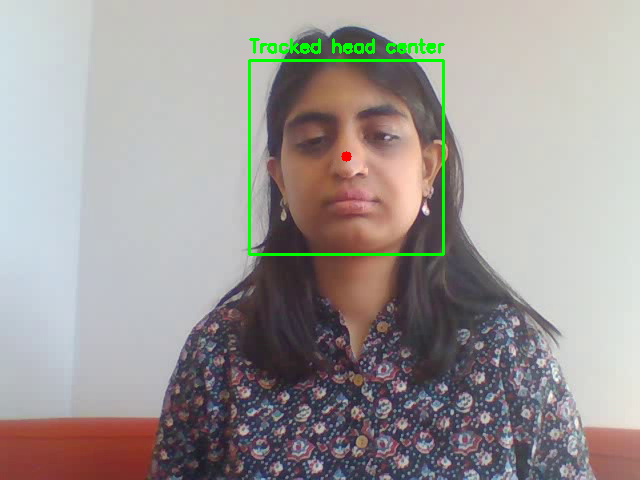

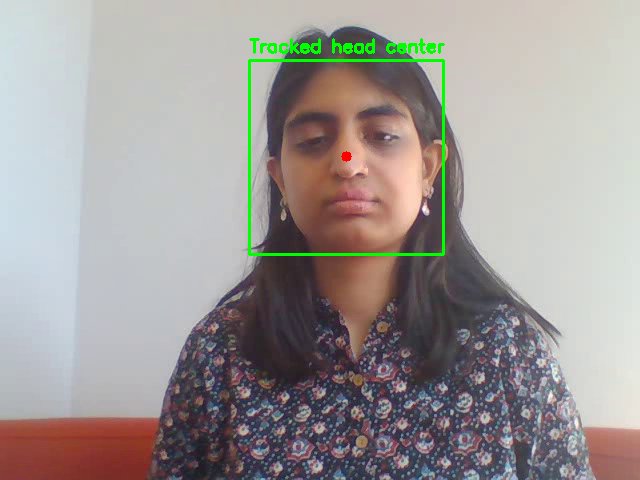

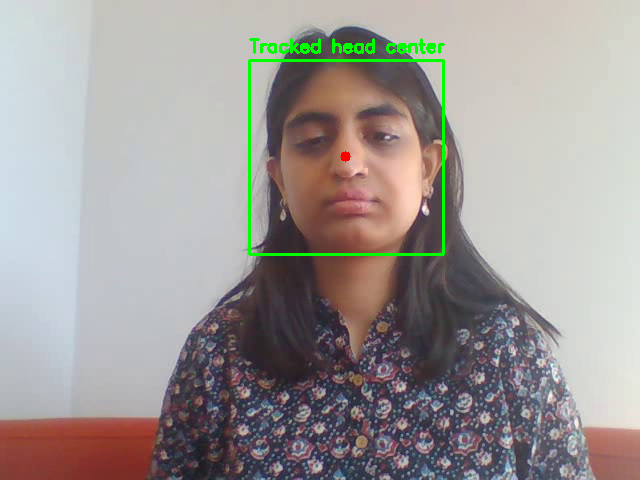

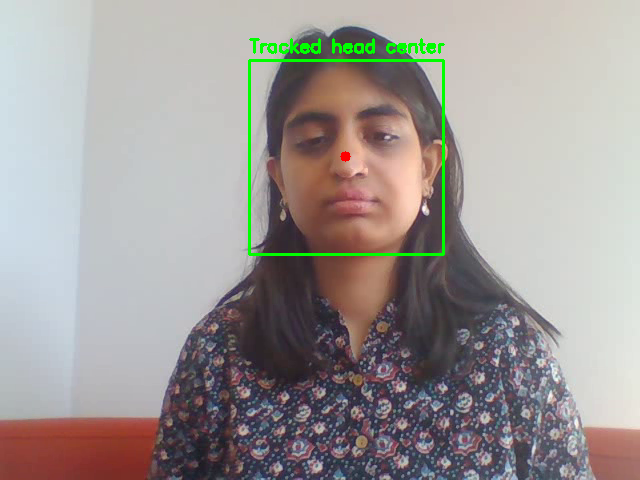


HEAD MOTION CLASSIFICATION RESULT
Video: shreshtha_stable_02.avi
Predicted class: stable
Confidence: 0.90

Motion details:
FPS: 30.00
Duration: 29.20 seconds
Valid tracking samples: 876
Valid tracking ratio: 1.000
Median face size: 187.00 px

Motion features:
x_amp: 0.0420
y_amp: 0.0297
total_amp: 0.0515
y_to_x_ratio: 0.7075
x_to_y_ratio: 1.4135
x_direction_changes: 0
y_direction_changes: 0
total_direction_changes: 0
path_length: 0.5480
used_trim: True


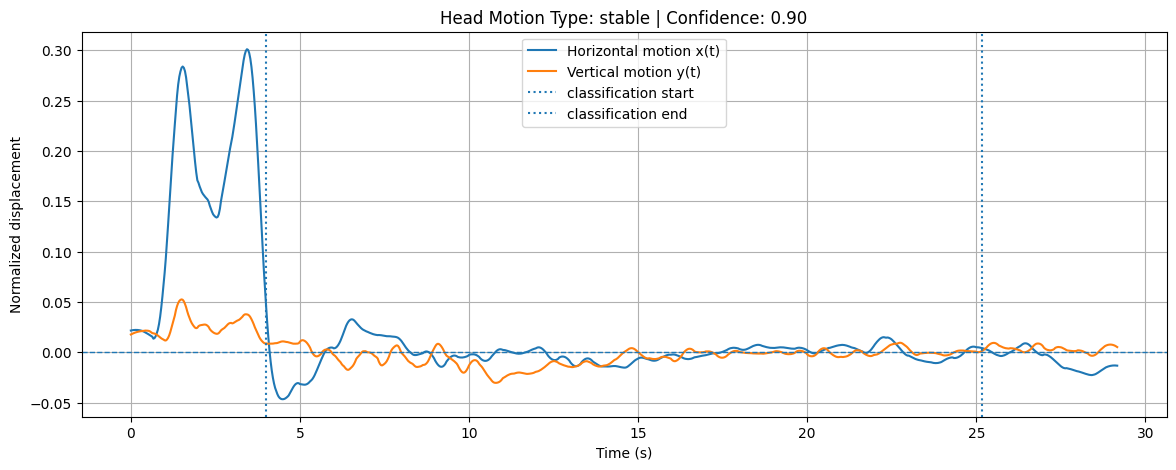


Final answer:
This video is classified as: stable


In [20]:
# =========================
# Single Video Head Motion Classifier for Google Colab
#
# Classes:
# - stable
# - left_right
# - zigzag
#
# Upload one video.
# The code predicts the head motion type.
#
# Updated version:
# - Trims first/last seconds for classification
# - Handles detector drift as stable
# - Removes tracking spikes/outliers
# - Requires real direction changes for left-right and zigzag
# =========================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from google.colab import files
from google.colab.patches import cv2_imshow


# =========================
# Upload one video
# =========================
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

print("Uploaded video:", video_path)


# =========================
# Settings
# =========================
SHOW_PREVIEW_FRAMES = True
DETECT_EVERY_N_FRAMES = 10
MIN_FACE_SIZE = (90, 90)

# Ignore beginning and ending parts for classification.
# This helps remove detector initialization drift and final tracking jumps.
CLASSIFICATION_TRIM_SECONDS = 4.0

# Stable thresholds
STABLE_X_THRESHOLD = 0.110
STABLE_Y_THRESHOLD = 0.110
STABLE_TOTAL_THRESHOLD = 0.140

# Drift-stable rule
# If there is no real repeated back-and-forth motion,
# classify as stable even if there is moderate tracking drift.
DRIFT_STABLE_TOTAL_THRESHOLD = 0.220
DRIFT_STABLE_MAX_X_CHANGES = 1
DRIFT_STABLE_MAX_Y_CHANGES = 2

# Left-right thresholds
LEFT_RIGHT_MIN_X = 0.120
LEFT_RIGHT_MAX_Y_TO_X_RATIO = 0.60
LEFT_RIGHT_MIN_X_CHANGES = 1

# Zigzag thresholds
ZIGZAG_MIN_X = 0.090
ZIGZAG_MIN_Y = 0.090
ZIGZAG_MIN_Y_TO_X_RATIO = 0.55
ZIGZAG_MIN_TOTAL_DIRECTION_CHANGES = 3

# Spike removal setting
SPIKE_Z_THRESHOLD = 3.5


# =========================
# Helper functions
# =========================
def largest_face(faces):
    if len(faces) == 0:
        return None

    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
    return faces[0]


def keep_box_inside_frame(box, frame_shape):
    x, y, w, h = box
    height, width = frame_shape[:2]

    x = max(0, int(x))
    y = max(0, int(y))
    w = max(1, min(int(w), width - x))
    h = max(1, min(int(h), height - y))

    return x, y, w, h


def expand_box(box, frame_shape, scale=1.15):
    x, y, w, h = box

    cx = x + w / 2.0
    cy = y + h / 2.0

    new_w = w * scale
    new_h = h * scale

    new_x = cx - new_w / 2.0
    new_y = cy - new_h / 2.0

    return keep_box_inside_frame((new_x, new_y, new_w, new_h), frame_shape)


def box_center(box):
    x, y, w, h = box
    return np.array([x + w / 2.0, y + h / 2.0], dtype=float)


def smooth_signal(signal):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 9:
        return signal

    window = min(21, len(signal))

    if window % 2 == 0:
        window -= 1

    if window < 7:
        return signal

    try:
        return savgol_filter(signal, window_length=window, polyorder=2)
    except Exception:
        return signal


def remove_spikes(signal, z_threshold=3.5):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 9:
        return signal

    cleaned = signal.copy()

    median_value = np.median(cleaned)
    mad = np.median(np.abs(cleaned - median_value)) + 1e-8

    robust_z = 0.6745 * (cleaned - median_value) / mad
    spike_mask = np.abs(robust_z) > z_threshold

    if np.sum(spike_mask) == 0:
        return cleaned

    valid_indices = np.where(~spike_mask)[0]
    spike_indices = np.where(spike_mask)[0]

    if len(valid_indices) < 5:
        return cleaned

    cleaned[spike_indices] = np.interp(
        spike_indices,
        valid_indices,
        cleaned[valid_indices]
    )

    return cleaned


def robust_range(signal, low=5, high=95):
    signal = np.asarray(signal, dtype=float)

    if len(signal) == 0:
        return 0.0

    return float(np.percentile(signal, high) - np.percentile(signal, low))


def count_direction_changes(signal, min_delta=0.004):
    signal = np.asarray(signal, dtype=float)

    if len(signal) < 5:
        return 0

    diff = np.diff(signal)

    # Remove tiny fluctuations
    diff[np.abs(diff) < min_delta] = 0.0

    signs = np.sign(diff)
    signs = signs[signs != 0]

    if len(signs) < 2:
        return 0

    return int(np.sum(signs[1:] != signs[:-1]))


def get_tracking_points(gray, face_box):
    x, y, w, h = expand_box(face_box, gray.shape, scale=1.10)

    mask = np.zeros_like(gray)
    mask[y:y+h, x:x+w] = 255

    points = cv2.goodFeaturesToTrack(
        gray,
        maxCorners=100,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7,
        mask=mask
    )

    return points


# =========================
# Extract head motion
# =========================
def extract_head_motion(video_path):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError("Video could not be opened.")

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps is None or fps <= 0:
        fps = 30.0

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames / fps if fps > 0 else 0

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    centers = []
    face_sizes = []
    frame_indices = []
    preview_frames = []

    prev_gray = None
    prev_points = None

    last_face = None
    last_center = None

    frame_index = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        need_detection = (
            last_face is None or
            prev_points is None or
            len(prev_points) < 10 or
            frame_index % DETECT_EVERY_N_FRAMES == 0
        )

        if need_detection:
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=4,
                minSize=MIN_FACE_SIZE
            )

            detected_face = largest_face(faces)

            if detected_face is not None:
                last_face = detected_face
                last_center = box_center(last_face)
                prev_points = get_tracking_points(gray, last_face)

        current_center = None

        if prev_gray is not None and prev_points is not None and len(prev_points) >= 5:
            next_points, status, error = cv2.calcOpticalFlowPyrLK(
                prev_gray,
                gray,
                prev_points,
                None,
                winSize=(21, 21),
                maxLevel=3,
                criteria=(
                    cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
                    30,
                    0.01
                )
            )

            if next_points is not None and status is not None:
                status = status.reshape(-1)

                good_new = next_points[status == 1]
                good_old = prev_points[status == 1]

                if len(good_new) >= 5:
                    median_shift = np.median(
                        good_new.reshape(-1, 2) - good_old.reshape(-1, 2),
                        axis=0
                    )

                    if last_center is not None:
                        current_center = last_center + median_shift
                        last_center = current_center

                    prev_points = good_new.reshape(-1, 1, 2)

        if current_center is None and last_face is not None:
            current_center = box_center(last_face)
            last_center = current_center

        if current_center is not None and last_face is not None:
            x, y, w, h = last_face
            face_size = max(float(w), float(h))

            centers.append(current_center)
            face_sizes.append(face_size)
            frame_indices.append(frame_index)

            if SHOW_PREVIEW_FRAMES and len(preview_frames) < 5:
                preview = frame.copy()

                x, y, w, h = keep_box_inside_frame(last_face, frame.shape)
                cx = int(current_center[0])
                cy = int(current_center[1])

                cv2.rectangle(
                    preview,
                    (x, y),
                    (x + w, y + h),
                    (0, 255, 0),
                    2
                )

                cv2.circle(
                    preview,
                    (cx, cy),
                    5,
                    (0, 0, 255),
                    -1
                )

                cv2.putText(
                    preview,
                    "Tracked head center",
                    (x, max(0, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

                preview_frames.append(preview)

        prev_gray = gray.copy()
        frame_index += 1

    cap.release()

    centers = np.asarray(centers, dtype=float)
    face_sizes = np.asarray(face_sizes, dtype=float)
    frame_indices = np.asarray(frame_indices, dtype=int)

    if len(centers) < 30:
        raise RuntimeError(
            "Not enough valid face tracking samples. "
            "Use a clearer video with better lighting and visible face."
        )

    median_face_size = float(np.median(face_sizes))

    if median_face_size <= 1:
        median_face_size = 1.0

    times = frame_indices / fps

    x_raw = centers[:, 0]
    y_raw = centers[:, 1]

    x_smooth = smooth_signal(x_raw)
    y_smooth = smooth_signal(y_raw)

    x_norm = (x_smooth - np.median(x_smooth)) / median_face_size
    y_norm = (y_smooth - np.median(y_smooth)) / median_face_size

    data = {
        "fps": fps,
        "total_frames": total_frames,
        "duration_sec": duration_sec,
        "valid_samples": len(centers),
        "valid_ratio": len(centers) / max(1, frame_index),
        "median_face_size": median_face_size,
        "times": times,
        "x_norm": x_norm,
        "y_norm": y_norm,
        "preview_frames": preview_frames
    }

    return data


# =========================
# Feature extraction
# =========================
def compute_features(data):
    x_all = np.asarray(data["x_norm"], dtype=float)
    y_all = np.asarray(data["y_norm"], dtype=float)
    times_all = np.asarray(data["times"], dtype=float)

    # Trim first and last seconds to reduce detector initialization/end drift
    if len(times_all) > 0:
        relative_time = times_all - times_all[0]
        duration = relative_time[-1]

        keep_mask = (
            (relative_time >= CLASSIFICATION_TRIM_SECONDS) &
            (relative_time <= duration - CLASSIFICATION_TRIM_SECONDS)
        )

        if np.sum(keep_mask) >= 30:
            x = x_all[keep_mask]
            y = y_all[keep_mask]
            used_trim = True
        else:
            x = x_all
            y = y_all
            used_trim = False
    else:
        x = x_all
        y = y_all
        used_trim = False

    # Remove tracking spikes/outliers before feature calculation
    x = remove_spikes(x, z_threshold=SPIKE_Z_THRESHOLD)
    y = remove_spikes(y, z_threshold=SPIKE_Z_THRESHOLD)

    # Smooth again after spike interpolation
    x = smooth_signal(x)
    y = smooth_signal(y)

    x_amp = robust_range(x)
    y_amp = robust_range(y)
    total_amp = float(np.sqrt(x_amp ** 2 + y_amp ** 2))

    y_to_x_ratio = float(y_amp / (x_amp + 1e-8))
    x_to_y_ratio = float(x_amp / (y_amp + 1e-8))

    x_changes = count_direction_changes(x)
    y_changes = count_direction_changes(y)

    path_length = float(
        np.sum(
            np.sqrt(
                np.diff(x) ** 2 +
                np.diff(y) ** 2
            )
        )
    )

    features = {
        "x_amp": x_amp,
        "y_amp": y_amp,
        "total_amp": total_amp,
        "y_to_x_ratio": y_to_x_ratio,
        "x_to_y_ratio": x_to_y_ratio,
        "x_direction_changes": x_changes,
        "y_direction_changes": y_changes,
        "total_direction_changes": x_changes + y_changes,
        "path_length": path_length,
        "used_trim": used_trim
    }

    return features


# =========================
# Classification
# =========================
def classify_motion(features):
    x_amp = features["x_amp"]
    y_amp = features["y_amp"]
    total_amp = features["total_amp"]
    y_to_x_ratio = features["y_to_x_ratio"]

    x_changes = features["x_direction_changes"]
    y_changes = features["y_direction_changes"]
    total_changes = features["total_direction_changes"]

    # Case 1: strong stable
    # Small motion in both x and y.
    if (
        x_amp < STABLE_X_THRESHOLD and
        y_amp < STABLE_Y_THRESHOLD and
        total_amp < STABLE_TOTAL_THRESHOLD
    ):
        predicted_class = "stable"
        confidence = 0.90

    # Case 2: stable with drift
    # This handles videos where the detector slowly drifts or jumps,
    # but there is no real repeated head motion.
    elif (
        total_amp < DRIFT_STABLE_TOTAL_THRESHOLD and
        x_changes <= DRIFT_STABLE_MAX_X_CHANGES and
        y_changes <= DRIFT_STABLE_MAX_Y_CHANGES
    ):
        predicted_class = "stable"
        confidence = 0.75

    # Case 3: left-right
    # Real left-right should have dominant x motion and at least one direction change.
    elif (
        x_amp >= LEFT_RIGHT_MIN_X and
        y_to_x_ratio <= LEFT_RIGHT_MAX_Y_TO_X_RATIO and
        x_changes >= LEFT_RIGHT_MIN_X_CHANGES
    ):
        predicted_class = "left_right"

        dominance = x_amp / (y_amp + 1e-8)
        confidence = 0.65 + 0.25 * min(dominance / 3.0, 1.0)
        confidence = min(confidence, 0.95)

    # Case 4: zigzag
    # Zigzag should have both x and y motion plus repeated direction changes.
    elif (
        x_amp >= ZIGZAG_MIN_X and
        y_amp >= ZIGZAG_MIN_Y and
        y_to_x_ratio >= ZIGZAG_MIN_Y_TO_X_RATIO and
        total_changes >= ZIGZAG_MIN_TOTAL_DIRECTION_CHANGES
    ):
        predicted_class = "zigzag"

        balance = 1.0 - min(
            abs(x_amp - y_amp) / (max(x_amp, y_amp) + 1e-8),
            1.0
        )

        change_score = min(total_changes / 8.0, 1.0)
        confidence = 0.60 + 0.20 * balance + 0.15 * change_score
        confidence = min(confidence, 0.95)

    # Fallback cases
    else:
        if total_amp < 0.170 and total_changes <= 2:
            predicted_class = "stable"
            confidence = 0.65

        # Important fallback:
        # If horizontal motion is very small, vertical spikes alone should not make it zigzag.
        elif x_amp < 0.050 and y_amp < 0.220:
            predicted_class = "stable"
            confidence = 0.65

        elif y_to_x_ratio < 0.70 and x_changes >= 1:
            predicted_class = "left_right"
            confidence = 0.65

        elif total_changes >= 3:
            predicted_class = "zigzag"
            confidence = 0.65

        else:
            predicted_class = "stable"
            confidence = 0.60

    return predicted_class, confidence


# =========================
# Run pipeline
# =========================
data = extract_head_motion(video_path)
features = compute_features(data)
predicted_class, confidence = classify_motion(features)


# =========================
# Show preview frames
# =========================
if SHOW_PREVIEW_FRAMES:
    print("\nPreview frames:")
    print("Green box = detected face")
    print("Red dot = tracked head center")

    for frame in data["preview_frames"]:
        cv2_imshow(frame)


# =========================
# Print result
# =========================
print("\n" + "=" * 60)
print("HEAD MOTION CLASSIFICATION RESULT")
print("=" * 60)

print("Video:", video_path)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2f}")

print("\nMotion details:")
print(f"FPS: {data['fps']:.2f}")
print(f"Duration: {data['duration_sec']:.2f} seconds")
print(f"Valid tracking samples: {data['valid_samples']}")
print(f"Valid tracking ratio: {data['valid_ratio']:.3f}")
print(f"Median face size: {data['median_face_size']:.2f} px")

print("\nMotion features:")
print(f"x_amp: {features['x_amp']:.4f}")
print(f"y_amp: {features['y_amp']:.4f}")
print(f"total_amp: {features['total_amp']:.4f}")
print(f"y_to_x_ratio: {features['y_to_x_ratio']:.4f}")
print(f"x_to_y_ratio: {features['x_to_y_ratio']:.4f}")
print(f"x_direction_changes: {features['x_direction_changes']}")
print(f"y_direction_changes: {features['y_direction_changes']}")
print(f"total_direction_changes: {features['total_direction_changes']}")
print(f"path_length: {features['path_length']:.4f}")
print(f"used_trim: {features['used_trim']}")


# =========================
# Plot motion signals
# =========================
times = data["times"]
relative_time = times - times[0]

plt.figure(figsize=(14, 5))
plt.plot(relative_time, data["x_norm"], label="Horizontal motion x(t)")
plt.plot(relative_time, data["y_norm"], label="Vertical motion y(t)")
plt.axhline(0, linestyle="--", linewidth=1)

# Show trimmed classification region
duration = relative_time[-1]

if duration > 2 * CLASSIFICATION_TRIM_SECONDS:
    plt.axvline(
        CLASSIFICATION_TRIM_SECONDS,
        linestyle=":",
        label="classification start"
    )

    plt.axvline(
        duration - CLASSIFICATION_TRIM_SECONDS,
        linestyle=":",
        label="classification end"
    )

plt.xlabel("Time (s)")
plt.ylabel("Normalized displacement")
plt.title(
    f"Head Motion Type: {predicted_class} | "
    f"Confidence: {confidence:.2f}"
)

plt.grid(True)
plt.legend()
plt.show()


# =========================
# Simple final message
# =========================
print("\nFinal answer:")
print(f"This video is classified as: {predicted_class}")